We are going to impute the Column for weight, since we have a lot of missing values.

Link to dataset docs: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
Link to imputation methods: https://towardsdatascience.com/different-imputation-methods-to-handle-missing-data-8dd5bce97583/ 

Weight can be the class we're trying to predict, the other features can be used to predict using Models like K-NN.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import collections
import seaborn as sb

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

seed = 1234
np.random.seed(seed)

X_labels = np.array(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed'])

In [2]:
diabities = pd.read_csv("training_data.csv")

In [3]:
df = pd.DataFrame(diabities)
df

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,83148,259912530,88114716,Caucasian,Female,[60-70),?,1,6,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
1,8067,37094196,604017,Caucasian,Female,[60-70),?,1,1,7,...,No,No,No,No,No,No,No,Ch,Yes,NO
2,19623,69819834,3401055,AfricanAmerican,Female,[40-50),?,1,6,7,...,No,No,No,No,No,No,No,No,No,>30
3,77236,234245010,71780013,Caucasian,Male,[70-80),?,2,6,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
4,55677,160693860,82716489,Caucasian,Female,[80-90),?,6,3,7,...,No,No,No,No,No,No,No,No,No,>30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,89460,289025640,50693553,Caucasian,Male,[80-90),?,1,6,7,...,No,No,No,No,No,No,No,Ch,Yes,NO
91585,60620,169681170,66287709,Caucasian,Male,[50-60),?,5,1,1,...,No,No,No,No,No,No,No,No,Yes,NO
91586,34086,106962006,24745671,Caucasian,Female,[80-90),?,2,1,4,...,No,Steady,No,No,No,No,No,No,Yes,NO
91587,58067,164976492,59602239,Caucasian,Female,[80-90),?,1,1,7,...,No,No,No,No,No,No,No,No,No,>30


In [4]:
df["weight"].unique()

array(['?', '[75-100)', '[100-125)', '[50-75)', '[125-150)', '[25-50)',
       '[0-25)', '[150-175)', '[175-200)', '>200'], dtype=object)

In [5]:
# Create a split for values that are non-null for weight
# df_weight = diabities_with_non_null_weight
df_weight = df[df['weight'] != '?']

In [6]:
df_weight

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
26,20988,73468026,68656032,Caucasian,Male,[70-80),[75-100),3,1,1,...,No,No,No,No,No,No,No,No,No,>30
44,33670,106185540,64203741,Caucasian,Male,[40-50),[100-125),1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
89,71395,206781078,69569415,?,Male,[70-80),[100-125),3,1,1,...,No,Steady,No,No,No,No,No,No,Yes,>30
121,72091,210300636,55808829,Caucasian,Female,[70-80),[75-100),1,6,7,...,No,No,No,No,No,No,No,No,Yes,NO
161,59490,167376852,98844102,Caucasian,Male,[40-50),[100-125),2,1,1,...,No,No,No,No,No,No,No,No,No,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91355,42243,130378080,98531514,Caucasian,Female,[80-90),[75-100),2,3,5,...,No,No,No,No,No,No,No,No,Yes,>30
91449,72520,212251254,33056145,Caucasian,Male,[60-70),[125-150),3,6,1,...,No,No,No,No,No,No,No,No,Yes,>30
91480,28530,93531624,76744422,Caucasian,Female,[50-60),[125-150),3,5,6,...,No,No,No,No,No,No,No,No,Yes,>30
91503,67267,188698692,57147984,Caucasian,Female,[60-70),[75-100),1,1,7,...,No,No,No,No,No,No,No,No,No,NO


### We can observe that our data entries for non-null weights are only 2.8k compared to 91k. We will take this to consideration when using our model for imputation

### Now we have train and test sets for weights

In [7]:
df_weight_tr, df_weight_te = train_test_split(df_weight, train_size=.9, test_size=.1, shuffle=True, random_state=seed)

### We need to do an Ordinal Label Encoder for weights to train our K-NN model

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder


# NOTE! - We have to use OneHotEncoding for nominal values instead of OrdinalEncoding. 
# This we will use Kaveh's ordinality split of columns.

In [8]:
# Ordinal vs nominal encoding with ColumnTransformer
# Ordinal: age, weight, max_glu_serum, A1Cresult, change, all meds (No < Steady < Up < Down), diabetesMed
# Nominal (one-hot): race, gender, payer_code, medical_specialty, diag_1, diag_2, diag_3
# Numeric (passthrough): admission_type_id, discharge_disposition_id, admission_source_id,
#   time_in_hospital, num_lab_*, number_*

cols_drop = ["Unnamed: 0", "encounter_id", "patient_nbr", "readmitted"]
ordinal_cols = ["age", "weight", "max_glu_serum", "A1Cresult", "change", "diabetesMed"] + [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]
nominal_cols = ["race", "gender", "payer_code", "medical_specialty", "diag_1", "diag_2", "diag_3"]
numeric_cols = ["admission_type_id", "discharge_disposition_id", "admission_source_id",
    "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]

# Build feature matrix (drop IDs and target)
def get_X(df):
    return df[[c for c in df.columns if c not in cols_drop]].copy()

X_tr = get_X(df_weight_tr)
X_te = get_X(df_weight_te)
ordinal_subset = [c for c in ordinal_cols if c in X_tr.columns]
nominal_subset = [c for c in nominal_cols if c in X_tr.columns]
numeric_subset = [c for c in numeric_cols if c in X_tr.columns]

preprocessor = ColumnTransformer([
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ordinal_subset),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nominal_subset),
    ("numeric", "passthrough", numeric_subset),
], remainder="drop", verbose_feature_names_out=True)

# Fit on training data only, then transform train and test
preprocessor.fit(X_tr)
X_tr_encoded = preprocessor.transform(X_tr)
X_te_encoded = preprocessor.transform(X_te)
feature_names = preprocessor.get_feature_names_out()
df_encoded_weight_tr = pd.DataFrame(X_tr_encoded, columns=feature_names)
df_encoded_weight_te = pd.DataFrame(X_te_encoded, columns=feature_names)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [9]:
df_encoded_weight_tr

,ordinal__age,ordinal__weight,ordinal__max_glu_serum,ordinal__A1Cresult,ordinal__change,ordinal__diabetesMed,ordinal__metformin,ordinal__repaglinide,ordinal__nateglinide,ordinal__chlorpropamide,...,numeric__discharge_disposition_id,numeric__admission_source_id,numeric__time_in_hospital,numeric__num_lab_procedures,numeric__num_procedures,numeric__num_medications,numeric__number_outpatient,numeric__number_emergency,numeric__number_inpatient,numeric__number_diagnoses
0,9.0,8.0,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,...,3.0,7.0,6.0,54.0,2.0,14.0,0.0,0.0,0.0,9.0
1,7.0,8.0,NaN,NaN,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,6.0,2.0,71.0,0.0,15.0,0.0,0.0,1.0,9.0
2,5.0,3.0,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,4.0,30.0,3.0,26.0,3.0,0.0,1.0,8.0
3,2.0,7.0,NaN,NaN,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,7.0,1.0,60.0,0.0,16.0,0.0,3.0,3.0,9.0
4,7.0,2.0,NaN,2.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,7.0,2.0,51.0,0.0,17.0,4.0,0.0,2.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2570,4.0,4.0,NaN,NaN,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,7.0,79.0,2.0,14.0,0.0,0.0,0.0,9.0
2571,7.0,8.0,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,17.0,1.0,71.0,0.0,7.0,0.0,0.0,0.0,7.0
2572,6.0,4.0,NaN,NaN,1.0,1.0,2.0,0.0,0.0,0.0,...,6.0,1.0,3.0,41.0,1.0,13.0,0.0,0.0,0.0,7.0
2573,6.0,8.0,NaN,NaN,0.0,1.0,2.0,0.0,0.0,0.0,...,1.0,7.0,8.0,69.0,0.0,10.0,1.0,0.0,0.0,9.0


In [10]:
df_encoded_weight_tr["ordinal__weight"]

0       8.0
1       8.0
2       3.0
3       7.0
4       2.0
       ... 
2570    4.0
2571    8.0
2572    4.0
2573    8.0
2574    8.0
Name: ordinal__weight, Length: 2575, dtype: float64

### Now we construct a correllation matrix

<Axes: >

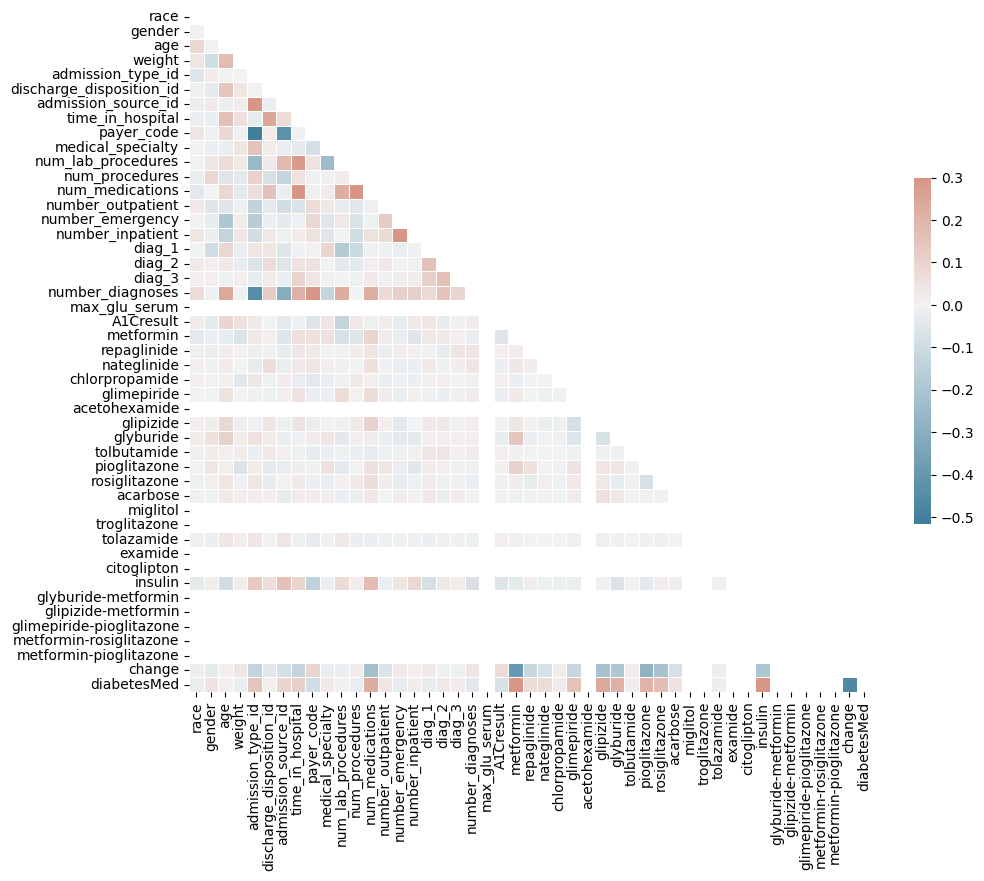

In [11]:
# Correlation matrix with same columns as training set (df_weight_tr features) so you see correlation between named features
X_tr = get_X(df_weight_tr)
corr_df = X_tr.copy()
# Ordinal-encode categorical columns so everything is numeric, keep original column names
obj_cols = corr_df.select_dtypes(include=["object"]).columns
if len(obj_cols) > 0:
    enc_corr = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    corr_df[obj_cols] = enc_corr.fit_transform(X_tr[obj_cols].astype(str))
# Now corr has same shape and column names as X_tr (age, weight, race, gender, ...)
corr = corr_df.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sb.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sb.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

### Now we extract the features that correlates to weight the most

In [12]:
# Features that correlate with weight the most (run the correlation cell above first so `corr` exists)
weight_corr = corr["weight"].drop("weight", errors="ignore")
weight_corr = weight_corr.reindex(weight_corr.sort_values(ascending=False).index)

# Optional: top N features by absolute correlation
top_n = 20
print(f"Top {top_n} features most correlated with weight (by absolute correlation):")
weight_corr.head(top_n)

# Optional: only features with |correlation| above a threshold
# corr_val = 0.1
# weight_corr[weight_corr.abs() >= corr_val]


Top 20 features most correlated with weight (by absolute correlation):


age                         0.175410
time_in_hospital            0.056839
A1Cresult                   0.055477
discharge_disposition_id    0.044025
race                        0.042311
medical_specialty           0.036294
change                      0.036134
number_inpatient            0.034942
num_lab_procedures          0.024921
number_emergency            0.022017
insulin                     0.020771
glyburide                   0.020160
admission_source_id         0.016067
tolbutamide                 0.015357
glipizide                   0.014733
diag_3                      0.012240
acarbose                    0.011258
tolazamide                  0.007259
repaglinide                 0.003270
admission_type_id          -0.000128
Name: weight, dtype: float64

### KNN to impute the "weight" feature

### We can observe a lot of NaN values for max_glu_serum and A1Cresult
### We can just drop them since the amount of data entries that have those missing values are close to the amount of training data we have.

**Improving KNN:** (1) **Scale features** with `StandardScaler` so distance isn’t dominated by high-variance columns. (2) **Tune k and weights** using `GridSearchCV` (e.g. odd k from 1 to 31, `weights` uniform vs distance) so you don’t rely on an arbitrary k.

In [13]:
df_encoded_weight_tr.isna().sum().sort_values(ascending=False).head(20)

ordinal__max_glu_serum    2575
ordinal__A1Cresult        2290
ordinal__age                 0
onehot__diag_2_E941          0
onehot__diag_2_V10           0
onehot__diag_2_E950          0
onehot__diag_2_E947          0
onehot__diag_2_E944          0
onehot__diag_2_E942          0
onehot__diag_2_E935          0
onehot__diag_2_E936          0
onehot__diag_2_V25           0
onehot__diag_2_E934          0
onehot__diag_2_E933          0
onehot__diag_2_E932          0
onehot__diag_2_E929          0
onehot__diag_2_V15           0
onehot__diag_2_V42           0
onehot__diag_2_E917          0
onehot__diag_2_V43           0
dtype: int64

In [18]:
# KNN improvements: (1) scale features, (2) tune k via cross-validation
weight_col = "ordinal__weight" if "ordinal__weight" in df_encoded_weight_tr.columns else "weight"
cols_to_remove = [weight_col, "ordinal__max_glu_serum" if "ordinal__max_glu_serum" in df_encoded_weight_tr.columns else "max_glu_serum", "ordinal__A1Cresult" if "ordinal__A1Cresult" in df_encoded_weight_tr.columns else "A1Cresult"]

y_weight_tr = df_encoded_weight_tr[weight_col]
X_weight_tr = df_encoded_weight_tr[df_encoded_weight_tr.columns.difference(cols_to_remove)]

y_weight_te = df_encoded_weight_te[weight_col]
X_weight_te = df_encoded_weight_te[df_encoded_weight_te.columns.difference(cols_to_remove)]

# 1. Scale features (KNN is distance-based; unscaled features dominate)
scaler = StandardScaler()
X_weight_tr = pd.DataFrame(scaler.fit_transform(X_weight_tr), columns=X_weight_tr.columns, index=X_weight_tr.index)
X_weight_te = pd.DataFrame(scaler.transform(X_weight_te), columns=X_weight_te.columns, index=X_weight_te.index)

# 2. Tune k and weights via cross-validation
param_grid = {"n_neighbors": list(range(1, 100, 2)), "weights": ["uniform", "distance"]}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_weight_tr, y_weight_tr)
print("Best params:", grid_search.best_params_, "| Best CV accuracy:", round(grid_search.best_score_, 4))
knn = grid_search.best_estimator_


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'n_neighbors': 37, 'weights': 'distance'} | Best CV accuracy: 0.4315


In [15]:
print(X_weight_tr.isna().sum().sum())
print(X_weight_te.isna().sum().sum())

0
0


### Now we are certain we have no NaN values, we can start fitting our data

In [19]:
knn.fit(X_weight_tr, y_weight_tr)

,n_neighbors,37
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
y_weight_pred_tr = knn.predict(X_weight_tr)
print("train: ", accuracy_score(y_weight_tr, y_weight_pred_tr))

y_weight_pred_te = knn.predict(X_weight_te)
print("test: ", accuracy_score(y_weight_te, y_weight_pred_te))

train:  1.0
test:  0.4076655052264808
